# Repairing a broken ligand network

In a relative binding free energy (RBFE) campaign, some transformations may fail.
If enough fail, the ligand network can become disconnected, and the ligands can no longer all be ranked against one another.

This cookbook follows the repair workflow end to end:

1. **Identify failures** from campaign results and reconstruct the damaged network.
2. **Repair the ligand network**, either manually or automatically by edge score.
3. **Build replacement transformations** for the newly proposed repair edges.

This example uses the hybrid topology RBFE protocol. The details of recovering protocol settings and constructing replacement Transformations are therefore protocol-specific. The broader workflow (identifying missing results, repairing the ligand network, and generating replacement transformations) is applicable to other RBFE protocols (e.g. SepTop) as well.

## Fetch the data

In [1]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"  # colab hack; not needed locally

# Fetch and extract the CLI tutorial results from Zenodo
!openfe fetch rbfe-tutorial-results
!tar -xf rbfe_results.tar.gz

Fetching /Users/hannahbaumann/.local/share/mamba/envs/openfe_env/lib/python3.12/site-packages/openfecli/tests/data/rbfe_results.tar.gz


## Imports

In [1]:
import copy
import json
import pathlib
import warnings
from collections.abc import Callable, Iterable

from rdkit import Chem
from gufe import AtomMapper, AtomMapping
from openfe import (
    AlchemicalNetwork,
    ChemicalSystem,
    LigandAtomMapping,
    LigandNetwork,
    ProteinComponent,
    SmallMoleculeComponent,
    SolventComponent,
    Transformation,
)
from openfe.protocols.openmm_rfe import RelativeHybridTopologyProtocol
from openfe.setup import KartografAtomMapper, lomap_scorers
from openfe.setup.ligand_network_planning import generate_network_from_names
from openfe.utils.atommapping_network_plotting import plot_atommapping_network
from gufe.tokenization import JSON_HANDLER

from konnektor.network_planners import MstConcatenator
from konnektor.network_tools import connected_subnetworks, merge_two_networks, delete_transformation

## 1. Identify the failures

Starting from the planned ligand network and the campaign results, we can determine which transformations did not complete successfully. Removing the corresponding edges gives the `damaged_network`, which contains only the successful transformations. We retain all input ligands from the planned network, including those for which no transformation finished successfully; such a ligand becomes an isolated node in the damaged network.

### Load the planned network

We start by loading the planned ligand network from `mst_network_tyk2.json`, which is the connected `LigandNetwork` the campaign set out to run.

planned connected: True
planned ligands: 10
planned edges: 9


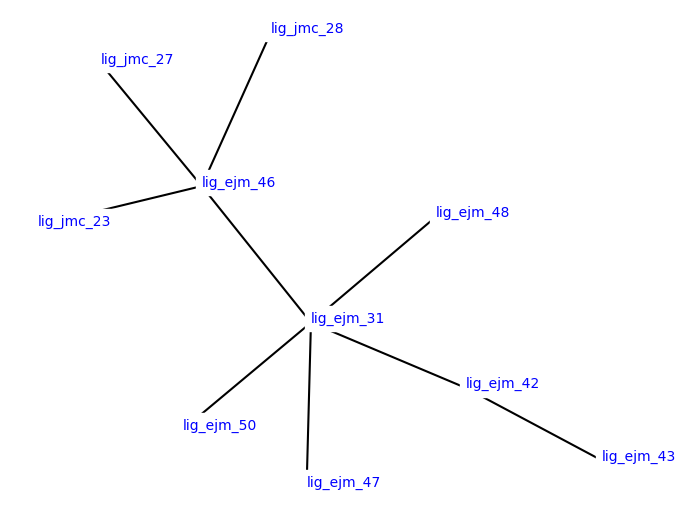

In [2]:
planned_network = LigandNetwork.from_json("assets/mst_network_tyk2.json")

print("planned connected:", planned_network.is_connected())
print("planned ligands:", len(planned_network.nodes))
print("planned edges:", len(planned_network.edges))

fig = plot_atommapping_network(planned_network)

### Parse the campaign results

For this example we simulate two failed transformations by omitting both legs of
their result files before parsing:

- `ejm_31 -- ejm_46`, which breaks a connection in the network;
- `ejm_31 -- ejm_48`, which removes `ejm_48` from the results entirely, since it was that ligand's only planned transformation.

For the hybrid topology protocol used in this example, a transformation is considered successful only when both its complex and solvent legs complete successfully.

While reading the results we also recover a reference complex `ChemicalSystem` (for its protein and cofactors) together with the
protocol settings. These are not needed to repair the ligand network itself, but
will be used in Part 3 to construct replacement transformations.

The result-processing and protocol-settings helper functions shown below are specific to the hybrid topology protocol. As mentioned above, the workflow can be adapted to other RBFE protocols.

In [3]:
def _load_result_json(path):
    """Load a usable result JSON, or return None."""
    result = json.load(open(path, "rb"), cls=JSON_HANDLER.decoder)

    if not isinstance(result, dict):
        return None
    if result.get("__qualname__") in ("AlchemicalNetwork", "Transformation"):
        return None
    if "unit_results" not in result:
        return None
    if all("exception" in unit for unit in result["unit_results"].values()):
        return None

    return result


def _units(result):
    data = result["protocol_result"]["data"]
    return data[next(iter(data))]


def _extract_result_edge(result):
    """Return (mapping, phase, stateA), or None if inputs are unavailable."""
    units = _units(result)
    if not units or "stateA" not in units[0]["inputs"]:
        return None

    inputs = units[0]["inputs"]
    state_a = ChemicalSystem.from_dict(inputs["stateA"])
    mapping = LigandAtomMapping.from_dict(inputs["ligandmapping"])

    is_complex = state_a.contains(ProteinComponent)

    return mapping, ("complex" if is_complex else "solvent"), state_a


def parse_results(result_files):
    """Return successful ligand mappings and campaign information."""
    phases_by_pair = {}
    mapping_by_pair = {}
    reference_complex_system = None
    reference_complex_mapping = None
    reference_protocol = None

    for path in result_files:
        result = _load_result_json(path)
        if result is None:
            continue

        if reference_protocol is None:
            settings = _units(result)[0]["inputs"].get("settings")
            reference_protocol = RelativeHybridTopologyProtocol(settings=settings)

        parsed = _extract_result_edge(result)
        if parsed is None:
            continue

        mapping, phase, state_a = parsed
        pair = frozenset((mapping.componentA.key, mapping.componentB.key))

        phases_by_pair.setdefault(pair, set()).add(phase)
        mapping_by_pair[pair] = mapping

        if phase == "complex" and reference_complex_system is None:
            reference_complex_system = state_a
            reference_complex_mapping = mapping

    successful_edges = [
        mapping_by_pair[pair]
        for pair, phases in phases_by_pair.items()
        if phases == {"complex", "solvent"}
    ]

    return successful_edges, reference_complex_system, reference_complex_mapping, reference_protocol

In [4]:
RESULTS_DIR = pathlib.Path("results")

result_files = sorted(
    path
    for path in RESULTS_DIR.rglob("*.json")
    if not any(part.startswith("shared_") for part in path.parts)
)
print(f"found {len(result_files)} result files")

# Simulate two failed transformations by dropping both legs from the result set.
DROP_EDGES = [
    ("ejm_31", "ejm_46"),
    ("ejm_31", "ejm_48"),
]

result_files = [
    path
    for path in result_files
    if not any(a in path.name and b in path.name for a, b in DROP_EDGES)
]

successful_edges, reference_complex_system, reference_complex_mapping, reference_protocol = parse_results(
    result_files
)

print("successful planned edges:", len(successful_edges))
print("recovered protocol:", reference_protocol is not None)

found 54 result files


/Users/hannahbaumann/.local/share/mamba/envs/openfe_dev/lib/python3.13/site-packages/gufe/components/smallmoleculecomponent.py:304: UserWarning: The atom hybridization data was not found and has been set to unspecified. This can be fixed by recreating the SmallMoleculeComponent from the rdkit molecule after running sanitization.
  warnings.warn(


successful planned edges: 7
recovered protocol: True


### Remove the failed edges from the plan

Transformations that are missing from the results are treated as failures. We therefore remove those edges from the planned `LigandNetwork` to reconstruct the network after the failures.

`delete_transformation` preserves all ligands in the network, even if removing an edge leaves a ligand isolated. 
Setting `must_stay_connected=False` allows the resulting network to be disconnected, giving us the broken network to repair.

failed edges: [('lig_ejm_31', 'lig_ejm_48'), ('lig_ejm_31', 'lig_ejm_46')]
damaged_network connected: False
damaged_network ligands: 10
damaged_network edges: 7


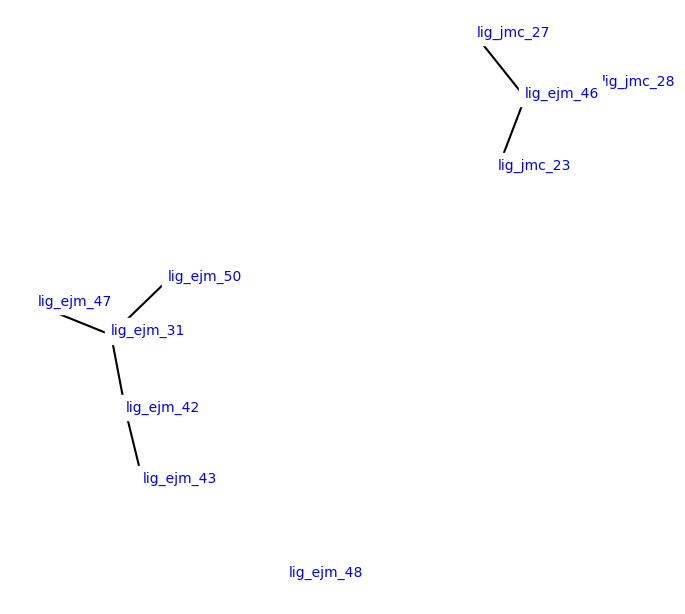

In [5]:
def _edge_pair(edge):
    """Return an unordered, serialization-stable ligand pair."""
    return frozenset((edge.componentA.name, edge.componentB.name))

successful_pairs = {_edge_pair(edge) for edge in successful_edges}
failed_edges = [
    edge
    for edge in planned_network.edges
    if _edge_pair(edge) not in successful_pairs
]

print(
    "failed edges:",
    [(edge.componentA.name, edge.componentB.name) for edge in failed_edges],
)

damaged_network = delete_transformation(
    planned_network,
    failed_edges,
    must_stay_connected=False,
)

print("damaged_network connected:", damaged_network.is_connected())
print("damaged_network ligands:", len(damaged_network.nodes))
print("damaged_network edges:", len(damaged_network.edges))

plot_atommapping_network(damaged_network)

## 2. Repair the ligand network

### Repair manually by ligand name

If you already know which ligand pairs should reconnect the network, you can specify those connections directly.

Here we select one ligand from each disconnected subnetwork and connect the
subnetworks in a chain. In a real campaign, these choices would typically be based
on chemical judgement or inspection.

In [6]:
def repair_network_by_names(
    ligand_network: LigandNetwork,
    names: list[tuple[str, str]],
    mapper: AtomMapper,
) -> tuple[LigandNetwork, list[AtomMapping]]:
    """Repair a ligand network using specified ligand pairs.

    New mappings are generated between the ligand pairs specified by ``names``
    and added to ``ligand_network``.

    Parameters
    ----------
    ligand_network : LigandNetwork
        The ligand network to repair.
    names : list[tuple[str, str]]
        Pairs of ligand names to connect. Each pair identifies the two ligands
        for which a new mapping should be generated.
    mapper : AtomMapper
        Atom mapper used to propose mappings between the specified ligand pairs.

    Returns
    -------
    repaired_network : LigandNetwork
        The ligand network with the new mappings added.
    new_edges : list[AtomMapping]
        The new mappings added to the ligand network.
    """
    repair_edges = generate_network_from_names(
        ligands=ligand_network.nodes,
        mapper=mapper,
        names=names,
    )

    repaired_network = merge_two_networks(
        ligand_network,
        repair_edges,
    )

    new_edges = set(repaired_network.edges) - set(ligand_network.edges)

    return repaired_network, list(new_edges)

/Users/hannahbaumann/.local/share/mamba/envs/openfe_dev/lib/python3.13/site-packages/konnektor/network_planners/generators/explicit_network_generator.py:85: UserWarning: Generated network is not connected as a single network.
  warnings.warn("Generated network is not connected as a single network.")


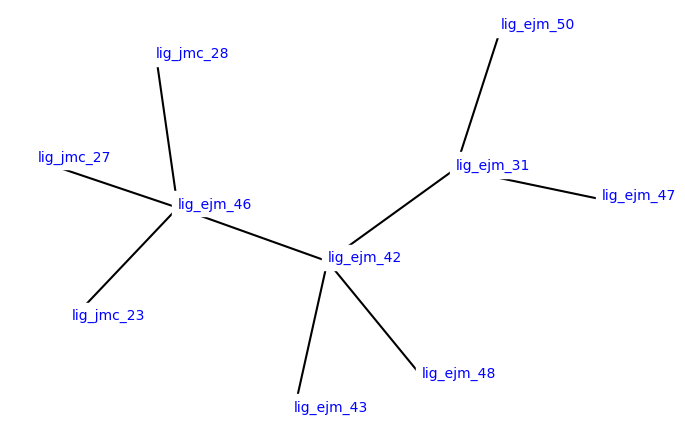

In [7]:
mapper = KartografAtomMapper()
repaired_by_name, new_edges_by_name = repair_network_by_names(
    damaged_network,
    names=[
        ("lig_ejm_42", "lig_ejm_46"),
        ("lig_ejm_42", "lig_ejm_48"),
    ],
    mapper=mapper,
)
plot_atommapping_network(repaired_by_name)

### Repair automatically by score

Instead of selecting the connections manually, we can use an `MstConcatenator` to score
candidate mappings between the disconnected subnetworks and select the edges needed
to reconnect the network.

The original planned edges are passed as `exclude_edges`, preventing the `MstConcatenator` from 
proposing ligand pairs that were already attempted in the original
campaign, including those corresponding to failed transformations.

In [8]:
def repair_network_by_score(
    ligand_network: LigandNetwork,
    mapper: AtomMapper,
    scorer: Callable[[AtomMapping], float],
    exclude_edges: Iterable[AtomMapping] | None = None,
) -> tuple[LigandNetwork, list[AtomMapping]]:
    """Repair a disconnected ligand network using scored mappings.

    The connected subnetworks of ``ligand_network`` are reconnected using a
    minimum spanning tree. Candidate mappings between subnetworks are generated
    with ``mapper`` and ranked using ``scorer``.

    Parameters
    ----------
    ligand_network : LigandNetwork
        The ligand network to repair.
    mapper : AtomMapper
        Atom mapper used to propose mappings between ligands in different
        connected subnetworks.
    scorer : Callable[[AtomMapping], float]
        Callable used to score proposed mappings.
    exclude_edges : Iterable[AtomMapping] | None, optional
        Mappings identifying ligand pairs that should not be used when
        reconnecting the network, by default None.

    Returns
    -------
    repaired_network : LigandNetwork
        The repaired, connected ligand network.
    new_edges : list[AtomMapping]
        The new mappings added to reconnect the ligand network.
    """
    subnetworks = connected_subnetworks(ligand_network)

    concatenator = MstConcatenator(
        mappers=mapper,
        scorer=scorer,
    )

    repaired_network = concatenator.concatenate_networks(
        subnetworks,
        exclude_edges=exclude_edges,
    )

    new_edges = set(repaired_network.edges) - set(ligand_network.edges)

    return repaired_network, list(new_edges)

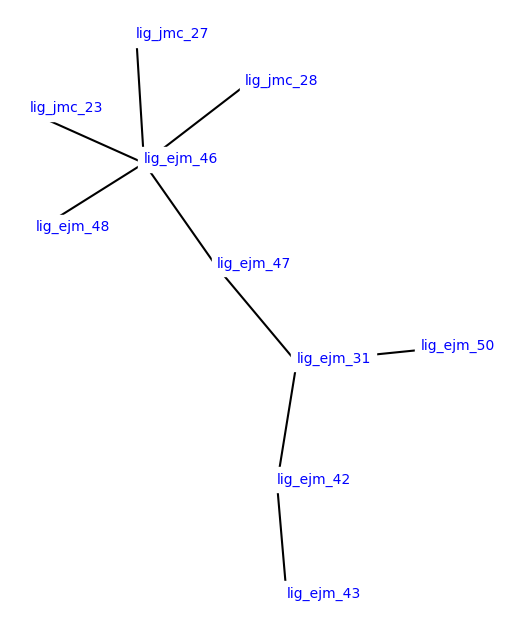

In [9]:
mapper = KartografAtomMapper()
scorer = lomap_scorers.default_lomap_score

repaired_by_score, new_edges_by_score = repair_network_by_score(
    damaged_network,
    mapper=mapper,
    scorer=scorer,
    exclude_edges=planned_network.edges,
)
plot_atommapping_network(repaired_by_score)

At this stage, the repaired ligand network is connected again. The repaired network contains both the existing and newly proposed edges, while `new_edges_by_score` contains only the new ligand mappings that still need to be simulated.

# 3. Build replacement transformations

The repair step produced new `LigandAtomMapping` edges. To continue the RBFE
campaign, these mappings must be turned into runnable solvent and complex
`Transformation`s.

We reuse the protein, solvent, cofactors, and protocol settings recovered from
the successful campaign results in Part 1. The replacement mappings in this example do not change ligand charge, but the workflow below also shows how charge-changing mappings can be handled by applying explicit charge-correction settings.

In [10]:
def _protocol_for(mapping, reference_protocol):
    """Reuse campaign settings and add charge correction when required."""
    if abs(mapping.get_alchemical_charge_difference()) < 1e-3:
        return reference_protocol

    from openff.units import unit

    settings = reference_protocol.settings.unfrozen_copy()
    settings.alchemical_settings.explicit_charge_correction = True
    settings.simulation_settings.production_length = 20 * unit.nanosecond
    settings.simulation_settings.n_replicas = 22
    settings.lambda_settings.lambda_windows = 22

    return RelativeHybridTopologyProtocol(settings=settings)


def _components_from_reference(reference_complex, mapping):
    protein = reference_complex.get_components_of_type(ProteinComponent)[0]

    solvent = reference_complex.get_components_of_type(SolventComponent)[0]

    small_molecules = reference_complex.get_components_of_type(
    SmallMoleculeComponent
    )
    
    cofactors = {
        component.name: component
        for component in small_molecules
        if component not in {
            mapping.componentA,
            mapping.componentB,
        }
    }

    return protein, solvent, cofactors


def build_alchemical_network(
    repair_edges,
    reference_complex_system,
    reference_complex_mapping,
    reference_protocol,
):
    """Create solvent and complex transformations for repair mappings."""
    protein, solvent, cofactors = _components_from_reference(
        reference_complex_system, reference_complex_mapping,
    )

    transformations = []

    for mapping in repair_edges:
        protocol = _protocol_for(mapping, reference_protocol)

        if protocol is not reference_protocol:
            warnings.warn(
                f"charge-changing edge {mapping.componentA.name} -> "
                f"{mapping.componentB.name}; added explicit charge correction"
            )

        for leg in ("solvent", "complex"):
            state_a_components = {
                "ligand": mapping.componentA,
                "solvent": solvent,
            }
            state_b_components = {
                "ligand": mapping.componentB,
                "solvent": solvent,
            }

            if leg == "complex":
                state_a_components["protein"] = protein
                state_b_components["protein"] = protein
                state_a_components.update(cofactors)
                state_b_components.update(cofactors)

            transformations.append(
                Transformation(
                    stateA=ChemicalSystem(state_a_components),
                    stateB=ChemicalSystem(state_b_components),
                    mapping=mapping,
                    protocol=protocol,
                    name=(
                        f"{leg}_"
                        f"{mapping.componentA.name}_"
                        f"{mapping.componentB.name}"
                    ),
                )
            )

    return AlchemicalNetwork(transformations)


def save_transformations(network, out_dir):
    out_dir = pathlib.Path(out_dir)
    transformations_dir = out_dir / "transformations"
    transformations_dir.mkdir(parents=True, exist_ok=True)

    with open(out_dir / "alchemical_network.json", "w") as file:
        json.dump(network.to_dict(), file, cls=JSON_HANDLER.encoder)

    for transformation in network.edges:
        transformation.to_json(
            transformations_dir / f"{transformation.name}.json"
        )

In [11]:
alchemical_network = build_alchemical_network(
    new_edges_by_score,
    reference_complex_system,
    reference_complex_mapping,
    reference_protocol,
)

save_transformations(
    alchemical_network,
    "repair_transformations",
)

print("wrote", len(alchemical_network.edges), "transformations")

wrote 4 transformations


## Summary

Repairing a disconnected ligand network involves three stages:

1. **Campaign results → failed planned edges**
2. **Damaged ligand network → new repair edges**
3. **New repair edges → runnable transformations**

The repaired network can be constructed either by selecting new connections manually
or by using mapping scores to select them automatically. The resulting new edges can
then be converted into replacement transformations and run to continue the campaign.